In [20]:
import pandas as pd
import os
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import shutil


test_file_path = 'csv/calc_case_description_test_set.csv'

test_df = pd.read_csv(test_file_path)



train_file_path = 'csv/calc_case_description_train_set.csv'

train_df = pd.read_csv(train_file_path)

print(f"Test df has {test_df.shape[0]} rows and {test_df.shape[1]} columns.")

print(f"Train df has {train_df.shape[0]} rows and {train_df.shape[1]} columns.")

print("Column names:", train_df.columns.tolist())

train_df.head()


Test df has 326 rows and 14 columns.
Train df has 1546 rows and 14 columns.
Column names: ['patient_id', 'breast density', 'left or right breast', 'image view', 'abnormality id', 'abnormality type', 'calc type', 'calc distribution', 'assessment', 'pathology', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path']


,patient_id,breast density,left or right breast,image view,abnormality id,abnormality type,calc type,calc distribution,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00005,3,RIGHT,CC,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_CC/1.3.6.1.4.1.959...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...
1,P_00005,3,RIGHT,MLO,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_MLO/1.3.6.1.4.1.95...,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....
2,P_00007,4,LEFT,CC,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00007,4,LEFT,MLO,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_MLO/1.3.6.1.4.1.959...,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9...,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00008,1,LEFT,CC,1,calcification,NaN,REGIONAL,2,BENIGN_WITHOUT_CALLBACK,3,Calc-Training_P_00008_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.95...


In [7]:
def izvadiImenaFoldera(df, col_name):
    list_of_folder_names = []
    for path in df[col_name]:
        path_elements = path.split('/')
        list_of_folder_names.append(path_elements[-2])
    return list_of_folder_names

def izvadiIDslika(df, col_name):
    image_IDs = []
    for path in df[col_name]:
        path_elements = path.split('/')
        image_IDs.append(path_elements[0])
    return image_IDs

def brojUniqueVal(df, col_name):
    unique_count = df[col_name].nunique()
    print(f"Number of unique values in the column {col_name}: {unique_count}")
    
        
test_data = {
    'ID': izvadiIDslika(test_df, "cropped image file path"),
    'Original image folder': izvadiImenaFoldera(test_df, "image file path"),
    'Cropped image folder': izvadiImenaFoldera(test_df, "cropped image file path"),
    'ROI mask folder': izvadiImenaFoldera(test_df, "ROI mask file path"),
}

# Create the DataFrame
test_df_folder_names = pd.DataFrame(test_data)       



# TESTIRANJE je li svaki ID stvarno jedinstven
brojUniqueVal(test_df_folder_names, 'ID')

# Broj originalnih slika
brojUniqueVal(test_df_folder_names, 'Original image folder')

# Broj foldera s cropped slikama
brojUniqueVal(test_df_folder_names, 'Cropped image folder')

# Broj foldera s ROI maskama
brojUniqueVal(test_df_folder_names, 'ROI mask folder')

# analiza dimenzija svih cropped slika da se dobije dojam koliko su generalno velike te slike? 
# ovako odokativno gledano bi širina i visina trebale biti između 200 i 400px
# plotanje dimenzija svake slike na graf da se provjeri ima li outliera (croppanih slika dimenzija znatno većih od 400x400 px)

test_df_folder_names


Number of unique values in the column ID: 326
Number of unique values in the column Original image folder: 284
Number of unique values in the column Cropped image folder: 326
Number of unique values in the column ROI mask folder: 326


,ID,Original image folder,Cropped image folder,ROI mask folder
0,Calc-Test_P_00038_LEFT_CC_1,1.3.6.1.4.1.9590.100.1.2.374115997511889073021...,1.3.6.1.4.1.9590.100.1.2.419081637812053404913...,1.3.6.1.4.1.9590.100.1.2.419081637812053404913...
1,Calc-Test_P_00038_LEFT_MLO_1,1.3.6.1.4.1.9590.100.1.2.174390361112646747718...,1.3.6.1.4.1.9590.100.1.2.188613955710170417803...,1.3.6.1.4.1.9590.100.1.2.188613955710170417803...
2,Calc-Test_P_00038_RIGHT_CC_1,1.3.6.1.4.1.9590.100.1.2.263861248711313923336...,1.3.6.1.4.1.9590.100.1.2.244876997513875090239...,1.3.6.1.4.1.9590.100.1.2.244876997513875090239...
3,Calc-Test_P_00038_RIGHT_CC_2,1.3.6.1.4.1.9590.100.1.2.263861248711313923336...,1.3.6.1.4.1.9590.100.1.2.360550081712464813321...,1.3.6.1.4.1.9590.100.1.2.360550081712464813321...
4,Calc-Test_P_00038_RIGHT_MLO_1,1.3.6.1.4.1.9590.100.1.2.442624602111129305133...,1.3.6.1.4.1.9590.100.1.2.126295284812046209819...,1.3.6.1.4.1.9590.100.1.2.126295284812046209819...
...,...,...,...,...
321,Calc-Test_P_02464_RIGHT_MLO_1,1.3.6.1.4.1.9590.100.1.2.242128209412592948513...,1.3.6.1.4.1.9590.100.1.2.526198631111753026131...,1.3.6.1.4.1.9590.100.1.2.526198631111753026131...
322,Calc-Test_P_02498_RIGHT_CC_1,1.3.6.1.4.1.9590.100.1.2.277098686410919869923...,1.3.6.1.4.1.9590.100.1.2.355286671810515664909...,1.3.6.1.4.1.9590.100.1.2.355286671810515664909...
323,Calc-Test_P_02498_RIGHT_MLO_1,1.3.6.1.4.1.9590.100.1.2.258951180113994815379...,1.3.6.1.4.1.9590.100.1.2.366216590611306753640...,1.3.6.1.4.1.9590.100.1.2.366216590611306753640...
324,Calc-Test_P_02501_RIGHT_CC_1,1.3.6.1.4.1.9590.100.1.2.232308535910657861814...,1.3.6.1.4.1.9590.100.1.2.275923704411531002833...,1.3.6.1.4.1.9590.100.1.2.275923704411531002833...


In [8]:
# provjeri postoji li isti broj pacijenta u train i test datasetu 
# ako postoji prevaci sve u jedan dataset

# distribucija svih klasa tumora

# u radu treba napomenuti da radimo već na train testu koji je balansiran (jednaki omjeri BENIGN, BENIGN_WITHOUT_CALLBACK i MALIGNANT uzoraka)
# Vjerojatno je izabrano ručno da bude tako. 
# Train dataset nije toliko balansiran (omjer otprilike 4:4:2). Napravit ću histograme koji će to lijepo ilustrirati

# IZRADA KLASIFIKACIJSKOG MODELA
# usporedba različitih feature extractora
# usporedba CNN i vision transformera (ako ostane vremena, trebalo bi bit jednostavno za implementaciju, ali nije nužno) 
# usporedba treniranja from scratch i predtreniranog modela (image net, foundation modeli -> težine iz modela koji su već učeni na slikama ultrazvuka)
# evaluacija: accuracy, konfuzijska mat., f1 score, overfitting., bogata diskusija
# 

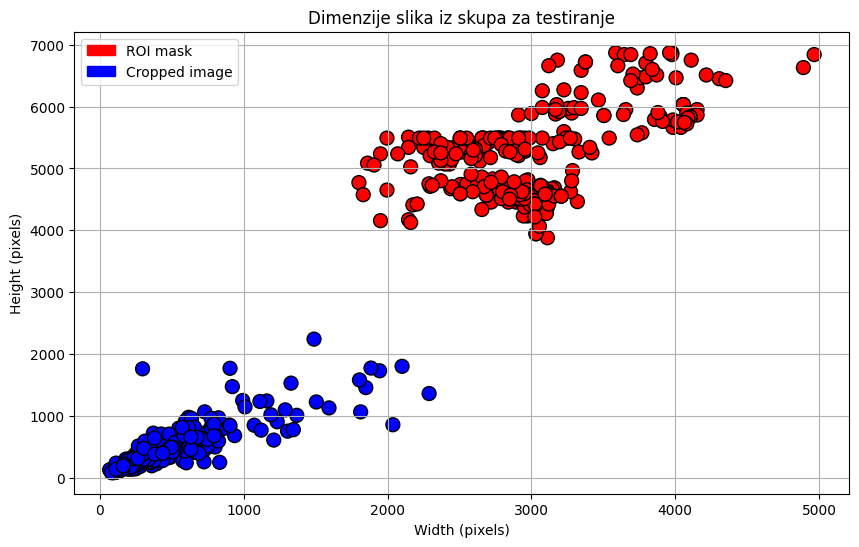

In [24]:


# df iz kojeg ćemo prikazivati dimenzije cropped slika i ROI mask slika
df = test_df_folder_names.copy()

# Initialize lists to store data for plotting
folder_list = []
widths = []
heights = []
colors = []  # To store color based on image size (red for bigger, blue for smaller)

# Loop through each folder and process the images
for folder in df['Cropped image folder']:
    folder_path = os.path.join('jpeg/', folder)  # Set your parent directory path
    if not os.path.exists(folder_path):
        print(f"Folder '{folder}' does not exist. Skipping.")
        continue
    
    image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('png', 'jpg', 'jpeg'))]

    # provjera da svaki folder ima točno 2 slike, croppanu i ROI mask
    if len(image_files) != 2:
        print(f"Folder '{folder}' does not contain exactly 2 image files. Skipping.")
        continue
    
    # Extract image dimensions
    img1_path = os.path.join(folder_path, image_files[0])
    img2_path = os.path.join(folder_path, image_files[1])
    
    with Image.open(img1_path) as img1, Image.open(img2_path) as img2:
        w1, h1 = img1.size
        w2, h2 = img2.size
        
        # Compute areas
        area1 = w1 * h1
        area2 = w2 * h2
        
        # Assign colors: red for larger image, blue for smaller
        if area1 > area2:
            folder_list.extend([folder, folder])
            widths.extend([w1, w2])
            heights.extend([h1, h2])
            colors.extend(['red', 'blue'])
        else:
            folder_list.extend([folder, folder])
            widths.extend([w1, w2])
            heights.extend([h1, h2])
            colors.extend(['blue', 'red'])

# Create a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(widths, heights, c=colors, label='Image Sizes', edgecolors='black', s=100)

# Add labels and legend
plt.title('Dimenzije slika iz skupa za testiranje')
plt.xlabel('Width (pixels)')
plt.ylabel('Height (pixels)')
plt.grid(True)
# Manually create legend handles
red_patch = mpatches.Patch(color='red', label='ROI mask')
blue_patch = mpatches.Patch(color='blue', label='Cropped image')

# Add legend
plt.legend(handles=[red_patch, blue_patch], loc='upper left')

# Show the plot
plt.show()

# vidljivo je da postoji očita razlika u dimenzijama između Cropped slika koje su manjih dimenzija i ROI mask slika koje su većih dimenzija 

In [18]:

# Parent directory where folders are stored
parent_dir = 'jpeg/'  # Replace with the path to your folders
output_dir = 'Test_cropped_images/'  # Directory where smaller images will be saved

# Create the output folder if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Loop through each folder and process the images
for index, row in df.iterrows():
    folder = row['Cropped image folder']
    rename_str = row['ID']
    folder_path = os.path.join(parent_dir, folder)
    
    if not os.path.exists(folder_path):
        print(f"Folder '{folder}' does not exist. Skipping.")
        continue
    
    # List all image files in the folder
    image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('png', 'jpg', 'jpeg'))]

    # provjera da svaki folder ima točno 2 slike, croppanu i ROI mask
    if len(image_files) != 2:
        print(f"Folder '{folder}' does not contain exactly 2 image files. Skipping.")
        continue
    
    # Extract image dimensions
    img1_path = os.path.join(folder_path, image_files[0])
    img2_path = os.path.join(folder_path, image_files[1])
    
    with Image.open(img1_path) as img1, Image.open(img2_path) as img2:
        w1, h1 = img1.size
        w2, h2 = img2.size
        
        # Compute areas
        area1 = w1 * h1
        area2 = w2 * h2
        
        # Determine the smaller image
        if area1 < area2:
            smaller_img_path = img1_path
        else:
            smaller_img_path = img2_path
        
        # Define the new filename using the rename string and original extension
        new_filename = f"{rename_str}.jpg"  # Change '.jpg' to match the image extension if needed
        
        # Copy and rename the smaller image
        dest_path = os.path.join(output_dir, new_filename)
        shutil.copy(smaller_img_path, dest_path)
        print(f"{index+1} Copied and renamed '{os.path.basename(smaller_img_path)}' to '{dest_path}'.")

print("Processing complete!")


1 Copied and renamed '1-245.jpg' to 'Test_cropped_images/Calc-Test_P_00038_LEFT_CC_1.jpg'.
2 Copied and renamed '1-246.jpg' to 'Test_cropped_images/Calc-Test_P_00038_LEFT_MLO_1.jpg'.
3 Copied and renamed '1-248.jpg' to 'Test_cropped_images/Calc-Test_P_00038_RIGHT_CC_1.jpg'.
4 Copied and renamed '1-247.jpg' to 'Test_cropped_images/Calc-Test_P_00038_RIGHT_CC_2.jpg'.
5 Copied and renamed '1-249.jpg' to 'Test_cropped_images/Calc-Test_P_00038_RIGHT_MLO_1.jpg'.
6 Copied and renamed '1-250.jpg' to 'Test_cropped_images/Calc-Test_P_00038_RIGHT_MLO_2.jpg'.
7 Copied and renamed '1-251.jpg' to 'Test_cropped_images/Calc-Test_P_00041_LEFT_CC_2.jpg'.
8 Copied and renamed '1-252.jpg' to 'Test_cropped_images/Calc-Test_P_00041_LEFT_MLO_2.jpg'.
9 Copied and renamed '1-253.jpg' to 'Test_cropped_images/Calc-Test_P_00077_LEFT_CC_1.jpg'.
10 Copied and renamed '1-254.jpg' to 'Test_cropped_images/Calc-Test_P_00077_LEFT_MLO_1.jpg'.
11 Copied and renamed '1-255.jpg' to 'Test_cropped_images/Calc-Test_P_00077_RIGH

In [23]:
# sada isti postupak treba napraviti za Train dataset

train_data = {
    'ID': izvadiIDslika(train_df, "cropped image file path"),
    'Original image folder': izvadiImenaFoldera(train_df, "image file path"),
    'Cropped image folder': izvadiImenaFoldera(train_df, "cropped image file path"),
    'ROI mask folder': izvadiImenaFoldera(train_df, "ROI mask file path"),
}

# Create the DataFrame
train_df_folder_names = pd.DataFrame(train_data)       

# TESTIRANJE je li svaki ID stvarno jedinstven
brojUniqueVal(train_df_folder_names, 'ID')

# Broj originalnih slika
brojUniqueVal(train_df_folder_names, 'Original image folder')

# Broj foldera s cropped slikama
brojUniqueVal(train_df_folder_names, 'Cropped image folder')

# Broj foldera s ROI maskama
brojUniqueVal(train_df_folder_names, 'ROI mask folder')

train_df_folder_names


Number of unique values in the column ID: 1546
Number of unique values in the column Original image folder: 1227
Number of unique values in the column Cropped image folder: 1546
Number of unique values in the column ROI mask folder: 1546


,ID,Original image folder,Cropped image folder,ROI mask folder
0,Calc-Training_P_00005_RIGHT_CC_1,1.3.6.1.4.1.9590.100.1.2.474143160103683865197...,1.3.6.1.4.1.9590.100.1.2.393344010211719049419...,1.3.6.1.4.1.9590.100.1.2.393344010211719049419...
1,Calc-Training_P_00005_RIGHT_MLO_1,1.3.6.1.4.1.9590.100.1.2.250596608311207922527...,1.3.6.1.4.1.9590.100.1.2.296281207812130400303...,1.3.6.1.4.1.9590.100.1.2.296281207812130400303...
2,Calc-Training_P_00007_LEFT_CC_1,1.3.6.1.4.1.9590.100.1.2.228699627313487111012...,1.3.6.1.4.1.9590.100.1.2.314135871111943890422...,1.3.6.1.4.1.9590.100.1.2.314135871111943890422...
3,Calc-Training_P_00007_LEFT_MLO_1,1.3.6.1.4.1.9590.100.1.2.104743410411133110629...,1.3.6.1.4.1.9590.100.1.2.914582796124855152034...,1.3.6.1.4.1.9590.100.1.2.914582796124855152034...
4,Calc-Training_P_00008_LEFT_CC_1,1.3.6.1.4.1.9590.100.1.2.406725628213826290127...,1.3.6.1.4.1.9590.100.1.2.281397494612871934937...,1.3.6.1.4.1.9590.100.1.2.281397494612871934937...
...,...,...,...,...
1541,Calc-Training_P_02566_RIGHT_MLO_1,1.3.6.1.4.1.9590.100.1.2.215164923711360518726...,1.3.6.1.4.1.9590.100.1.2.126466180112225633704...,1.3.6.1.4.1.9590.100.1.2.126466180112225633704...
1542,Calc-Training_P_02572_LEFT_CC_1,1.3.6.1.4.1.9590.100.1.2.398227953312611741920...,1.3.6.1.4.1.9590.100.1.2.144395473912570122935...,1.3.6.1.4.1.9590.100.1.2.144395473912570122935...
1543,Calc-Training_P_02572_LEFT_MLO_1,1.3.6.1.4.1.9590.100.1.2.832140770136026940308...,1.3.6.1.4.1.9590.100.1.2.177833786212905547113...,1.3.6.1.4.1.9590.100.1.2.177833786212905547113...
1544,Calc-Training_P_02584_LEFT_CC_1,1.3.6.1.4.1.9590.100.1.2.114030713125639071286...,1.3.6.1.4.1.9590.100.1.2.420697654133217172227...,1.3.6.1.4.1.9590.100.1.2.420697654133217172227...


Folder '1.3.6.1.4.1.9590.100.1.2.27611247910023474515584644283556391565' does not contain exactly 2 image files. Skipping.
Folder '1.3.6.1.4.1.9590.100.1.2.348822970413183698610798947061334416506' does not exist. Skipping.


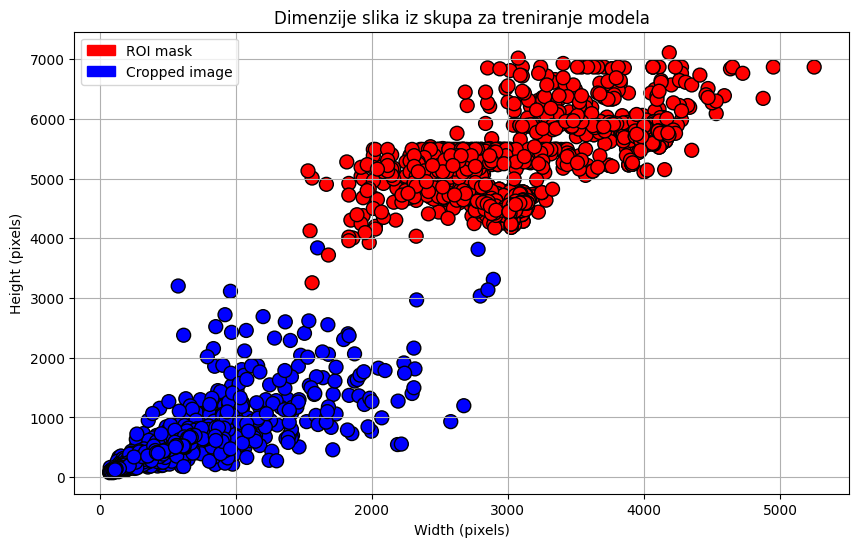

In [26]:


# df iz kojeg ćemo prikazivati dimenzije cropped slika i ROI mask slika
df = train_df_folder_names.copy()

# Initialize lists to store data for plotting
folder_list = []
widths = []
heights = []
colors = []  # To store color based on image size (red for bigger, blue for smaller)

# Loop through each folder and process the images
for folder in df['Cropped image folder']:
    folder_path = os.path.join('jpeg/', folder)  # Set your parent directory path
    if not os.path.exists(folder_path):
        print(f"Folder '{folder}' does not exist. Skipping.")
        continue
    
    image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('png', 'jpg', 'jpeg'))]

    # provjera da svaki folder ima točno 2 slike, croppanu i ROI mask
    if len(image_files) != 2:
        print(f"Folder '{folder}' does not contain exactly 2 image files. Skipping.")
        continue
    
    # Extract image dimensions
    img1_path = os.path.join(folder_path, image_files[0])
    img2_path = os.path.join(folder_path, image_files[1])
    
    with Image.open(img1_path) as img1, Image.open(img2_path) as img2:
        w1, h1 = img1.size
        w2, h2 = img2.size
        
        # Compute areas
        area1 = w1 * h1
        area2 = w2 * h2
        
        # Assign colors: red for larger image, blue for smaller
        if area1 > area2:
            folder_list.extend([folder, folder])
            widths.extend([w1, w2])
            heights.extend([h1, h2])
            colors.extend(['red', 'blue'])
        else:
            folder_list.extend([folder, folder])
            widths.extend([w1, w2])
            heights.extend([h1, h2])
            colors.extend(['blue', 'red'])

# Create a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(widths, heights, c=colors, label='Image Sizes', edgecolors='black', s=100)

# Add labels and legend
plt.title('Dimenzije slika iz skupa za treniranje modela')
plt.xlabel('Width (pixels)')
plt.ylabel('Height (pixels)')
plt.grid(True)
# Manually create legend handles
red_patch = mpatches.Patch(color='red', label='ROI mask')
blue_patch = mpatches.Patch(color='blue', label='Cropped image')

# Add legend
plt.legend(handles=[red_patch, blue_patch], loc='upper left')

# Show the plot
plt.show()

# Budući da skup podataka za treniranje sadeži mnogo više slika od testnog skupa, za očekivati je da će imati više outliera. 
# Vidimo da su neke slike, iako su croppane, i dalje velikih dimenzija.
# pretpostavit ćemo da će u jednom folderu koji sadrži ROI masku i croppanu sliku, croppana slika uvijek imati manju površinu.
# Uzet ćemo manju sliku (za koju pretpostavljamo da je croppana) iz svakog foldera i kopirati ju u folder "Train_cropped_images".
# nakon toga ćemo vizualno prekontrolirati sve slike u tom folderu, a ako se potkrala ijedna ROI mask slika ručno ćemo ju izbrisati iz dataseta.

In [35]:
# Parent directory where folders are stored
parent_dir = 'jpeg/'  # Replace with the path to your folders
output_dir = 'Train_cropped_images/'  # Directory where smaller images will be saved
invalid_rows = []
# Create the output folder if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Loop through each folder and process the images
for index, row in df.iterrows():
    folder = row['Cropped image folder']
    rename_str = row['ID']
    folder_path = os.path.join(parent_dir, folder)
    
    if not os.path.exists(folder_path):
        print(f"Folder '{folder}' does not exist. Skipping.")
        invalid_rows.append(row['ID'])
        continue
    
    # List all image files in the folder
    image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('png', 'jpg', 'jpeg'))]

    # provjera da svaki folder ima točno 2 slike, croppanu i ROI mask
    if len(image_files) != 2:
        print(f"Folder '{folder}' does not contain exactly 2 image files. Skipping.")
        invalid_rows.append(row['ID'])
        continue
    
    # Extract image dimensions
    img1_path = os.path.join(folder_path, image_files[0])
    img2_path = os.path.join(folder_path, image_files[1])
    
    with Image.open(img1_path) as img1, Image.open(img2_path) as img2:
        w1, h1 = img1.size
        w2, h2 = img2.size
        
        # Compute areas
        area1 = w1 * h1
        area2 = w2 * h2
        
        # Determine the smaller image
        if area1 < area2:
            smaller_img_path = img1_path
        else:
            smaller_img_path = img2_path
        
        # Define the new filename using the rename string and original extension
        new_filename = f"{rename_str}.jpg"  # Change '.jpg' to match the image extension if needed
        
        # Copy and rename the smaller image
        dest_path = os.path.join(output_dir, new_filename)
        shutil.copy(smaller_img_path, dest_path)
        print(f"{index+1} Copied and renamed '{os.path.basename(smaller_img_path)}' to '{dest_path}'.")

print("Processing complete!")
print(invalid_rows)

1 Copied and renamed '2-191.jpg' to 'Train_cropped_images/Calc-Training_P_00005_RIGHT_CC_1.jpg'.
2 Copied and renamed '1-192.jpg' to 'Train_cropped_images/Calc-Training_P_00005_RIGHT_MLO_1.jpg'.
3 Copied and renamed '1-193.jpg' to 'Train_cropped_images/Calc-Training_P_00007_LEFT_CC_1.jpg'.
4 Copied and renamed '1-194.jpg' to 'Train_cropped_images/Calc-Training_P_00007_LEFT_MLO_1.jpg'.
5 Copied and renamed '1-195.jpg' to 'Train_cropped_images/Calc-Training_P_00008_LEFT_CC_1.jpg'.
6 Copied and renamed '1-196.jpg' to 'Train_cropped_images/Calc-Training_P_00008_LEFT_CC_2.jpg'.
7 Copied and renamed '1-197.jpg' to 'Train_cropped_images/Calc-Training_P_00008_LEFT_CC_3.jpg'.
8 Copied and renamed '1-198.jpg' to 'Train_cropped_images/Calc-Training_P_00008_LEFT_MLO_1.jpg'.
9 Copied and renamed '1-199.jpg' to 'Train_cropped_images/Calc-Training_P_00008_LEFT_MLO_2.jpg'.
10 Copied and renamed '1-200.jpg' to 'Train_cropped_images/Calc-Training_P_00008_LEFT_MLO_3.jpg'.
11 Copied and renamed '1-201.jpg

In [37]:
final_train = train_df.copy()
final_train.insert(0, 'ID', train_df_folder_names['ID'])

final_train = final_train.drop(columns=['image file path', 'cropped image file path', 'ROI mask file path'])
final_train = final_train[~final_train['ID'].isin(invalid_rows)]
final_train.to_csv('train_data.csv', index=False)
final_train

,ID,patient_id,breast density,left or right breast,image view,abnormality id,abnormality type,calc type,calc distribution,assessment,pathology,subtlety
0,Calc-Training_P_00005_RIGHT_CC_1,P_00005,3,RIGHT,CC,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3
1,Calc-Training_P_00005_RIGHT_MLO_1,P_00005,3,RIGHT,MLO,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3
2,Calc-Training_P_00007_LEFT_CC_1,P_00007,4,LEFT,CC,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4
3,Calc-Training_P_00007_LEFT_MLO_1,P_00007,4,LEFT,MLO,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4
4,Calc-Training_P_00008_LEFT_CC_1,P_00008,1,LEFT,CC,1,calcification,NaN,REGIONAL,2,BENIGN_WITHOUT_CALLBACK,3
...,...,...,...,...,...,...,...,...,...,...,...,...
1541,Calc-Training_P_02566_RIGHT_MLO_1,P_02566,2,RIGHT,MLO,1,calcification,AMORPHOUS-PLEOMORPHIC,SEGMENTAL,5,MALIGNANT,5
1542,Calc-Training_P_02572_LEFT_CC_1,P_02572,2,LEFT,CC,1,calcification,AMORPHOUS,CLUSTERED,0,MALIGNANT,2
1543,Calc-Training_P_02572_LEFT_MLO_1,P_02572,2,LEFT,MLO,1,calcification,AMORPHOUS,CLUSTERED,0,MALIGNANT,2
1544,Calc-Training_P_02584_LEFT_CC_1,P_02584,1,LEFT,CC,1,calcification,PLEOMORPHIC,SEGMENTAL,0,BENIGN,4


In [38]:
final_test = test_df.copy()
final_test.insert(0, 'ID', test_df_folder_names['ID'])

final_test = final_test.drop(columns=['image file path', 'cropped image file path', 'ROI mask file path'])

final_test.to_csv('test_data.csv', index=False)
final_test

,ID,patient_id,breast density,left or right breast,image view,abnormality id,abnormality type,calc type,calc distribution,assessment,pathology,subtlety
0,Calc-Test_P_00038_LEFT_CC_1,P_00038,2,LEFT,CC,1,calcification,PUNCTATE-PLEOMORPHIC,CLUSTERED,4,BENIGN,2
1,Calc-Test_P_00038_LEFT_MLO_1,P_00038,2,LEFT,MLO,1,calcification,PUNCTATE-PLEOMORPHIC,CLUSTERED,4,BENIGN,2
2,Calc-Test_P_00038_RIGHT_CC_1,P_00038,2,RIGHT,CC,1,calcification,VASCULAR,NaN,2,BENIGN_WITHOUT_CALLBACK,5
3,Calc-Test_P_00038_RIGHT_CC_2,P_00038,2,RIGHT,CC,2,calcification,VASCULAR,NaN,2,BENIGN_WITHOUT_CALLBACK,5
4,Calc-Test_P_00038_RIGHT_MLO_1,P_00038,2,RIGHT,MLO,1,calcification,VASCULAR,NaN,2,BENIGN_WITHOUT_CALLBACK,5
...,...,...,...,...,...,...,...,...,...,...,...,...
321,Calc-Test_P_02464_RIGHT_MLO_1,P_02464,2,RIGHT,MLO,1,calcification,FINE_LINEAR_BRANCHING,CLUSTERED,0,MALIGNANT,4
322,Calc-Test_P_02498_RIGHT_CC_1,P_02498,4,RIGHT,CC,1,calcification,PUNCTATE,CLUSTERED,0,BENIGN,3
323,Calc-Test_P_02498_RIGHT_MLO_1,P_02498,4,RIGHT,MLO,1,calcification,PUNCTATE,CLUSTERED,0,BENIGN,3
324,Calc-Test_P_02501_RIGHT_CC_1,P_02501,3,RIGHT,CC,1,calcification,PLEOMORPHIC,CLUSTERED,0,MALIGNANT,3
